In [1]:
from pycirclize import Circos
import numpy as np
import pyreadr
np.random.seed(0)
import matplotlib.pyplot as plt
import allel
import zarr
import numcodecs
import sys
import pandas as pd
from collections import *
from sklearn.cluster import KMeans
from matplotlib.legend_handler import HandlerLine2D

In [2]:
def getSectors():
    # Define a function to generate random sectors for the Circos plot
    sectors = []
    with open(chromSize, 'r') as inf:
        for i in inf:
            chrID, chrLen = i.strip().split()
            sector[chrID] = int(chrlen) / 1000000
            

In [ ]:
def getMDS():
    # Define a function to generate multidimensional scaling (MDS) coordinates for the Circos plot
    

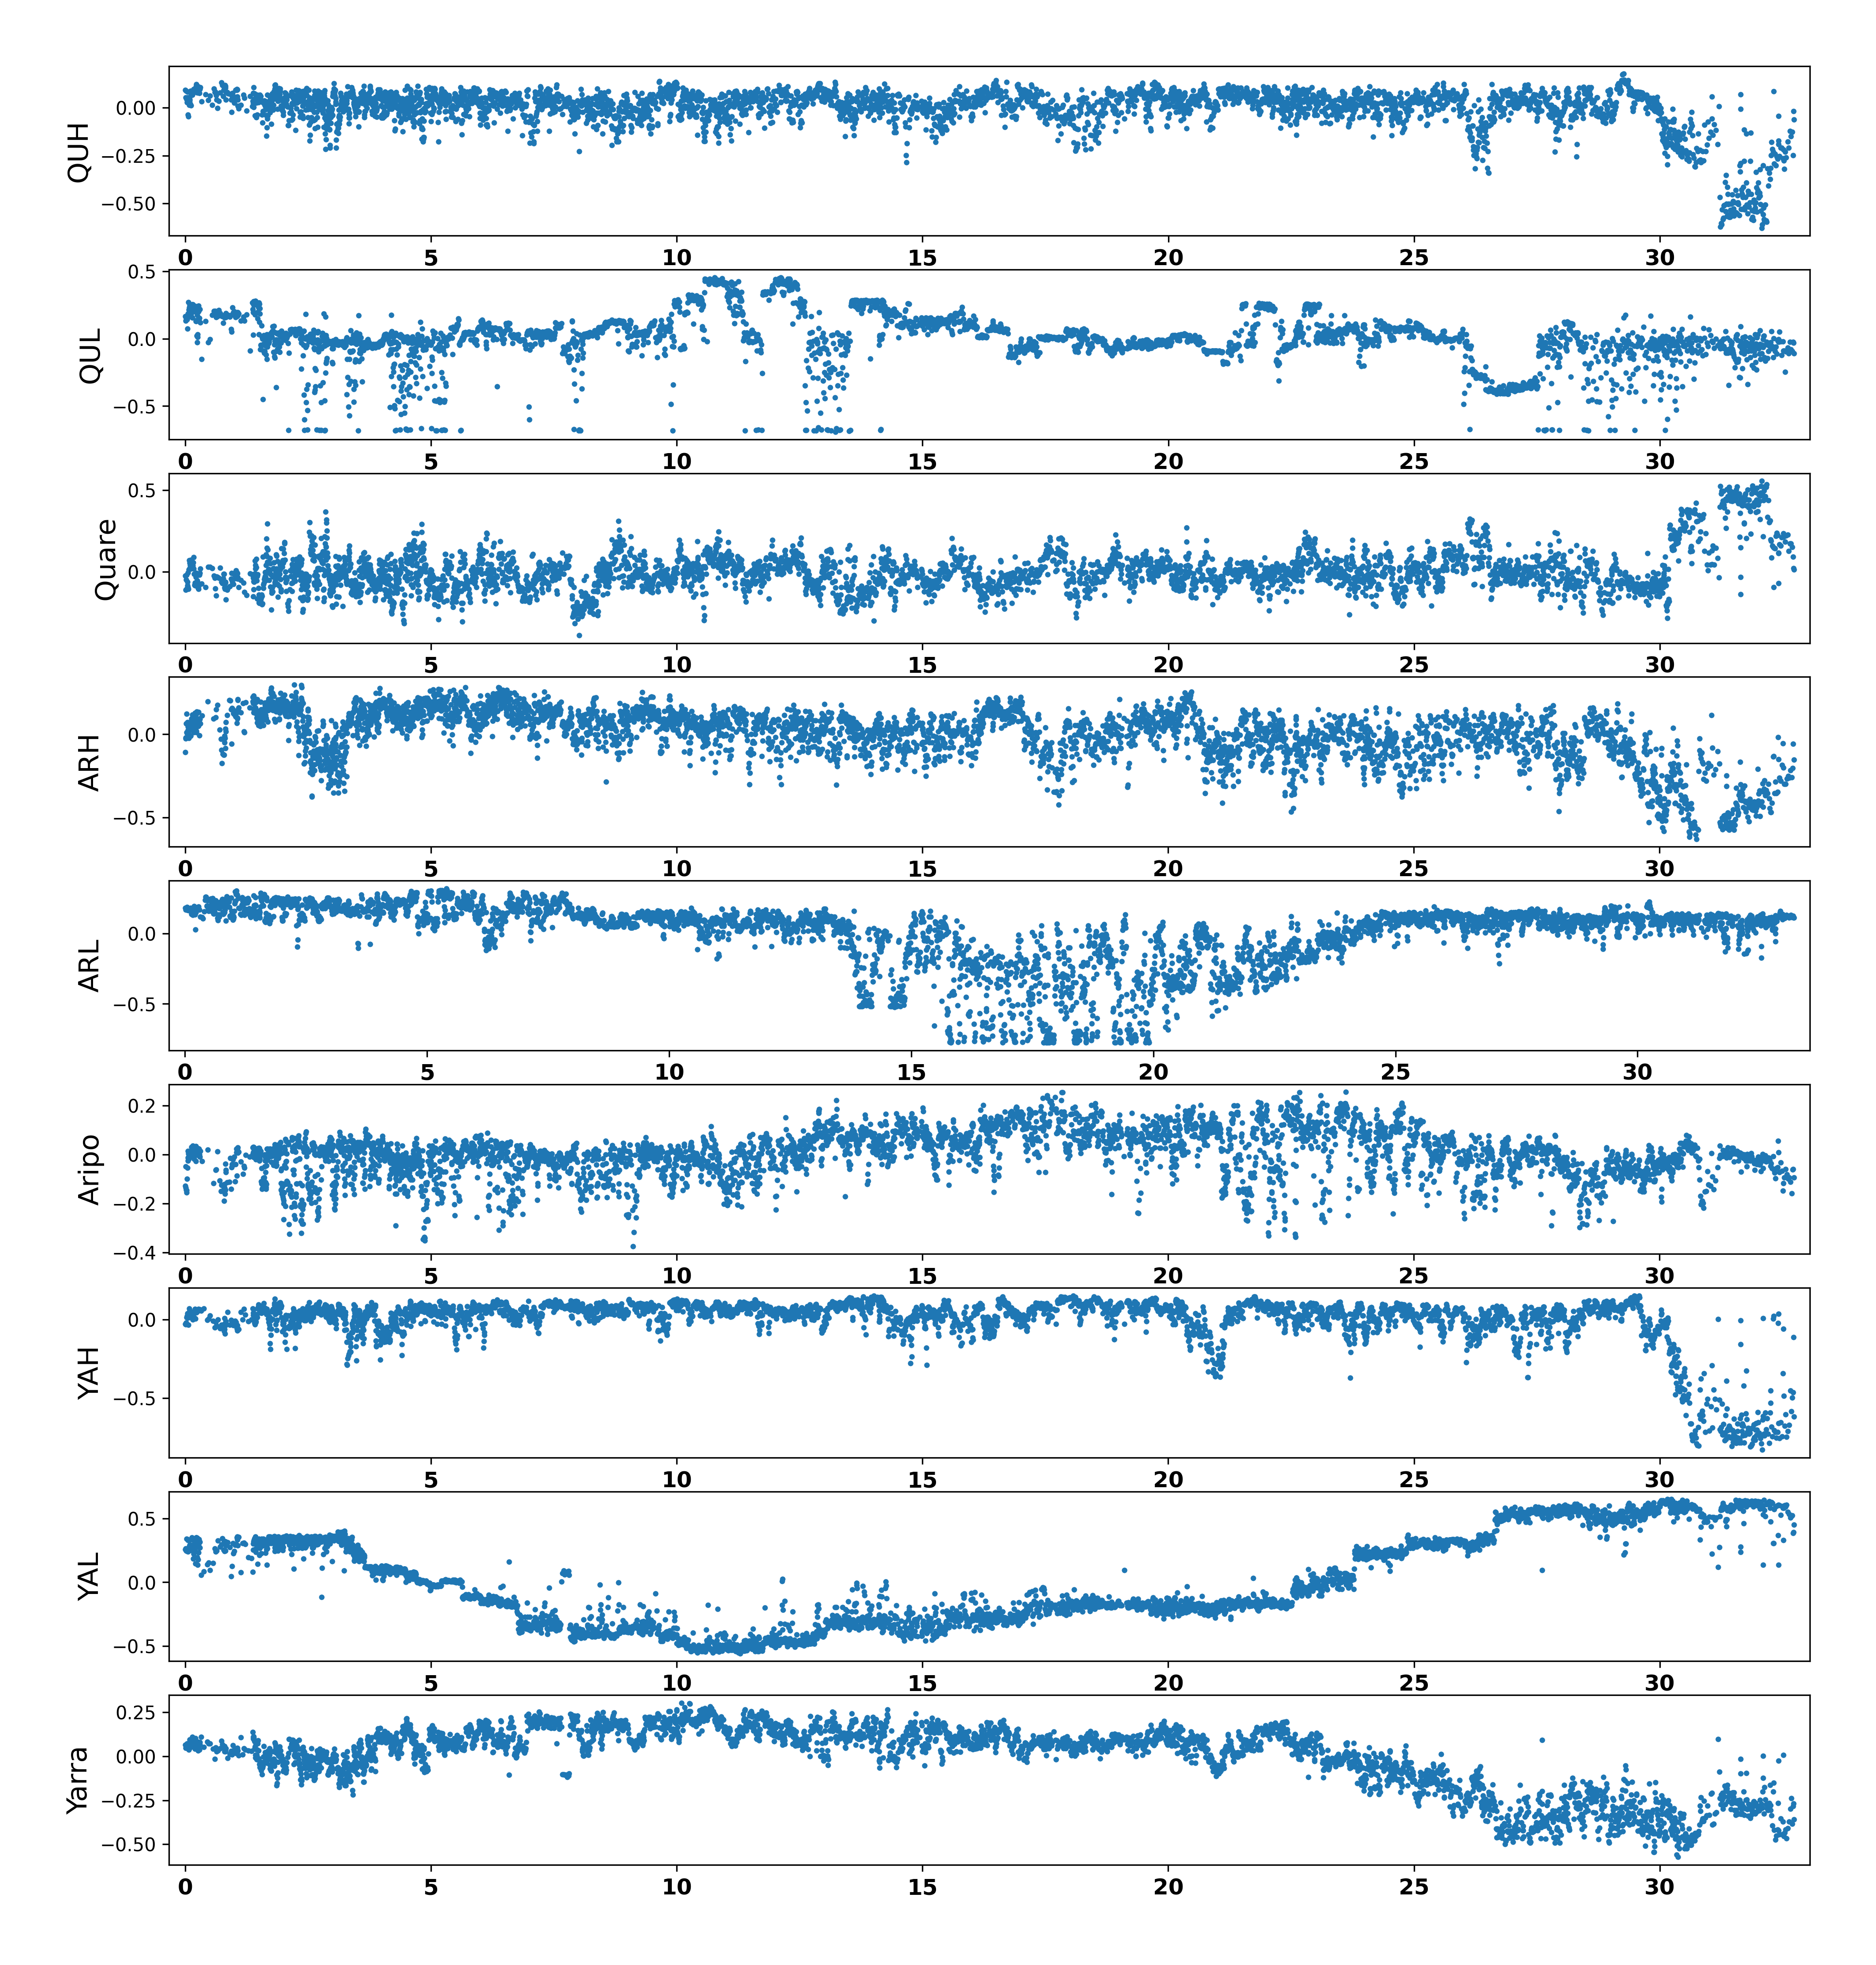

In [68]:
fig, axs = plt.subplots(9, 1, figsize=(16,18), dpi=300)
LG = 4
#plt.rcParams["axes.labelweight"] = "bold"
################### Quare river #########################
Quare_high_result = pyreadr.read_r("/Users/rainlam/Project/3.SV/localPCA/male_guppy_genome/MDS/QUH.LG{}.win100.lostruct.windows.rds".format(LG))
Quare_low_result = pyreadr.read_r("/Users/rainlam/Project/3.SV/localPCA/male_guppy_genome/MDS/QUL.LG{}.win100.lostruct.windows.rds".format(LG))
Quare_all_result = pyreadr.read_r("/Users/rainlam/Project/3.SV/localPCA/male_guppy_genome/MDS/Quare.LG{}.win100.lostruct.windows.rds".format(LG))
################### Aripo river #########################
Aripo_high_result = pyreadr.read_r("/Users/rainlam/Project/3.SV/localPCA/male_guppy_genome/MDS/ARH.LG{}.win100.lostruct.windows.rds".format(LG))
#Aripo_low_result = pyreadr.read_r("/Users/rainlam/Project/3.SV/localPCA/male_guppy_genome/MDS/ARL.LG{}.win100.lostruct.windows.rds".format(LG))
Aripo_all_result = pyreadr.read_r("/Users/rainlam/Project/3.SV/localPCA/male_guppy_genome/MDS/Aripo.LG{}.win100.lostruct.windows.rds".format(LG))
################### Yarra river #########################
Yarra_high_result = pyreadr.read_r("/Users/rainlam/Project/3.SV/localPCA/male_guppy_genome/MDS/YAH.LG{}.win100.lostruct.windows.rds".format(LG))
Yarra_low_result = pyreadr.read_r("/Users/rainlam/Project/3.SV/localPCA/male_guppy_genome/MDS/YAL.LG{}.win100.lostruct.windows.rds".format(LG))
Yarra_all_result = pyreadr.read_r("/Users/rainlam/Project/3.SV/localPCA/male_guppy_genome/MDS/Yarra.LG{}.100.lostruct.windows.rds".format(LG))

rivers = ["Quare", "Aripo", "Yarra"]
pops = ["high", "low", "all"]
subplot = 0

for river in rivers:
    for pop in pops:
        river_pop_result = river + "_" + pop + "_" + "result"
        if pop == "all":
            axs[subplot].set_ylabel(river, fontsize=15)
            for k,v in eval(river_pop_result).items():
                x = v["mid"] /1000000
                y = v["mds02"]
        else:
            axs[subplot].set_ylabel((river[:2] + pop[0]).upper(), fontsize=15)
            
            for k,v in eval(river_pop_result).items():
                x = v["mid"] /1000000
                y = v["mds01"]
        axs[subplot].scatter(x,y)                       
        axs[subplot].margins(x=0.01)
        axs[subplot].set_xticks(range(0, 35, 5), labels=[0,5,10,15,20,25,30],fontsize=12, fontweight="bold") 
        #axs[subplot].set_ylim(-1,1)
        
        subplot += 1
    

# for k,v in result2.items():
#     x = v["mid"] /1000000
#     y = v["mds01"]
# axs[1].scatter(x,y)                       
# axs[1].margins(x=0.01)
# axs[1].set_xticks(range(0, 35, 5), labels=[0,5,10,15,20,25,30],fontsize=12, fontweight="bold")  
# axs[1].set_ylim(-1,0.5)
# axs[1].set_ylabel("QUL", fontsize=15)

# for k,v in result3.items():
#     x = v["mid"] /1000000
#     y = v["mds02"]
# axs[2].scatter(x,y)                       
# axs[2].margins(x=0.01)
# axs[2].set_xticks(range(0, 35, 5), labels=[0,5,10,15,20,25,30],fontsize=12, fontweight="bold") 
# #axs[2].set_ylim(-0.25,0.75)
# axs[2].set_ylabel("Quare", fontsize=15)
# plt.xlabel("LG7 (Mb)", fontsize=13, fontweight="bold")


In [38]:
river_pop_result

'Yarra_all_result'

In [3]:
#vcf_path = "/Users/rainlam/QUL/QUL.LG1.vcf.gz"
vcf_path = "/Users/rainlam/Project/3.SV/Quare.LG7.vcf.gz"

# extract genotype data from VCF file 
#callset = allel.read_vcf(vcf_path, region='LR880645.1:18500000-20500000')
chromosome = "LR880651.1"
start = 0
end = "5000000"
callset = allel.read_vcf(vcf_path, region='{}:{}-{}'.format(chromosome, start, end))
# ['ArL-F10', 'ArL-F15', 'ArL-F16', 'ArL-F18',
#        'ArL-F19', 'ArL-F20', 'ArL-F22', 'ArL-F5', 'ArL-F8', 'ArL-F9',
#        'ArL-M11', 'ArL-M12', 'ARL-M15', 'ArL-M16', 'ARL-M17', 'ArL-M19',
#        'ArL-M1', 'ArL-M24', 'ARL-M25', 'ArL-M6']
#callset = allel.read_vcf(vcf_path)
# genotype 
g = allel.GenotypeArray(callset['calldata/GT'])

In [4]:
ac = g.count_alleles()[:]
# SNP filtering
flt = (ac.max_allele() == 1) & (ac[:, :2].min(axis=1) > 1)
gf = g.compress(flt, axis=0)
gn = gf.to_n_alt()
gn

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 2],
       [0, 0, 0, ..., 1, 0, 2],
       [2, 2, 2, ..., 2, 2, 2]], dtype=int8)

In [5]:
coords1, model1 = allel.pca(gn, n_components=10, scaler='patterson')

In [6]:
sample_list = []
for i in range(len(callset['samples'])):
    het_count = g[:,i].count_het()
    prop_het_sample = het_count*100 / 1500000
    sample_list.append([callset['samples'][i], coords1[i][0], coords1[i][1], prop_het_sample])
df = pd.DataFrame(sample_list, columns=["samples",
                                        "PC1", "PC2", "hetero"])
X = df[['PC1']]
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)

In [7]:
kmeans.fit(X)
df_cl = X.copy()
# add one more column
df_cl['cluster'] = kmeans.predict(X)
df_cl
df["cluster"] = kmeans.predict(X)
#df["sex"] = ["M"]*10 + ['F'] *10
df["sex"] = ["F"]*10 + ['M'] *9 + ["F"]*10 + ['M'] *10 
#df["sex"] = ["F"]*10 + ['M'] *10 
df['pop'] = ['QUH'] * 19 + ['QUL'] * 20

In [8]:
df

,samples,PC1,PC2,hetero,cluster,sex,pop
0,QuH-F12,-361.903931,70.560081,2.081000,0,F,QUH
1,QuH-F13,-381.072845,116.587921,1.943067,0,F,QUH
2,QuH-F21,-58.416664,-195.871429,1.330867,2,F,QUH
3,QuH-F22,-55.847080,-133.949875,1.250533,2,F,QUH
4,QuH-F25,-28.644463,-146.619049,1.301867,2,F,QUH
5,QuH-F3,-31.400677,-119.184731,1.284600,2,F,QUH
6,QuH-F4,-239.403961,123.948738,1.768600,0,F,QUH
7,QuH-F6,-342.353302,114.663673,1.822667,0,F,QUH
8,QuH-F7,-1.703602,-19.499018,1.382000,2,F,QUH
9,QuH-F9,-28.750156,-129.918060,1.064600,2,F,QUH


Text(0, 0.5, 'Heterzygosity')

<Figure size 3000x2000 with 0 Axes>

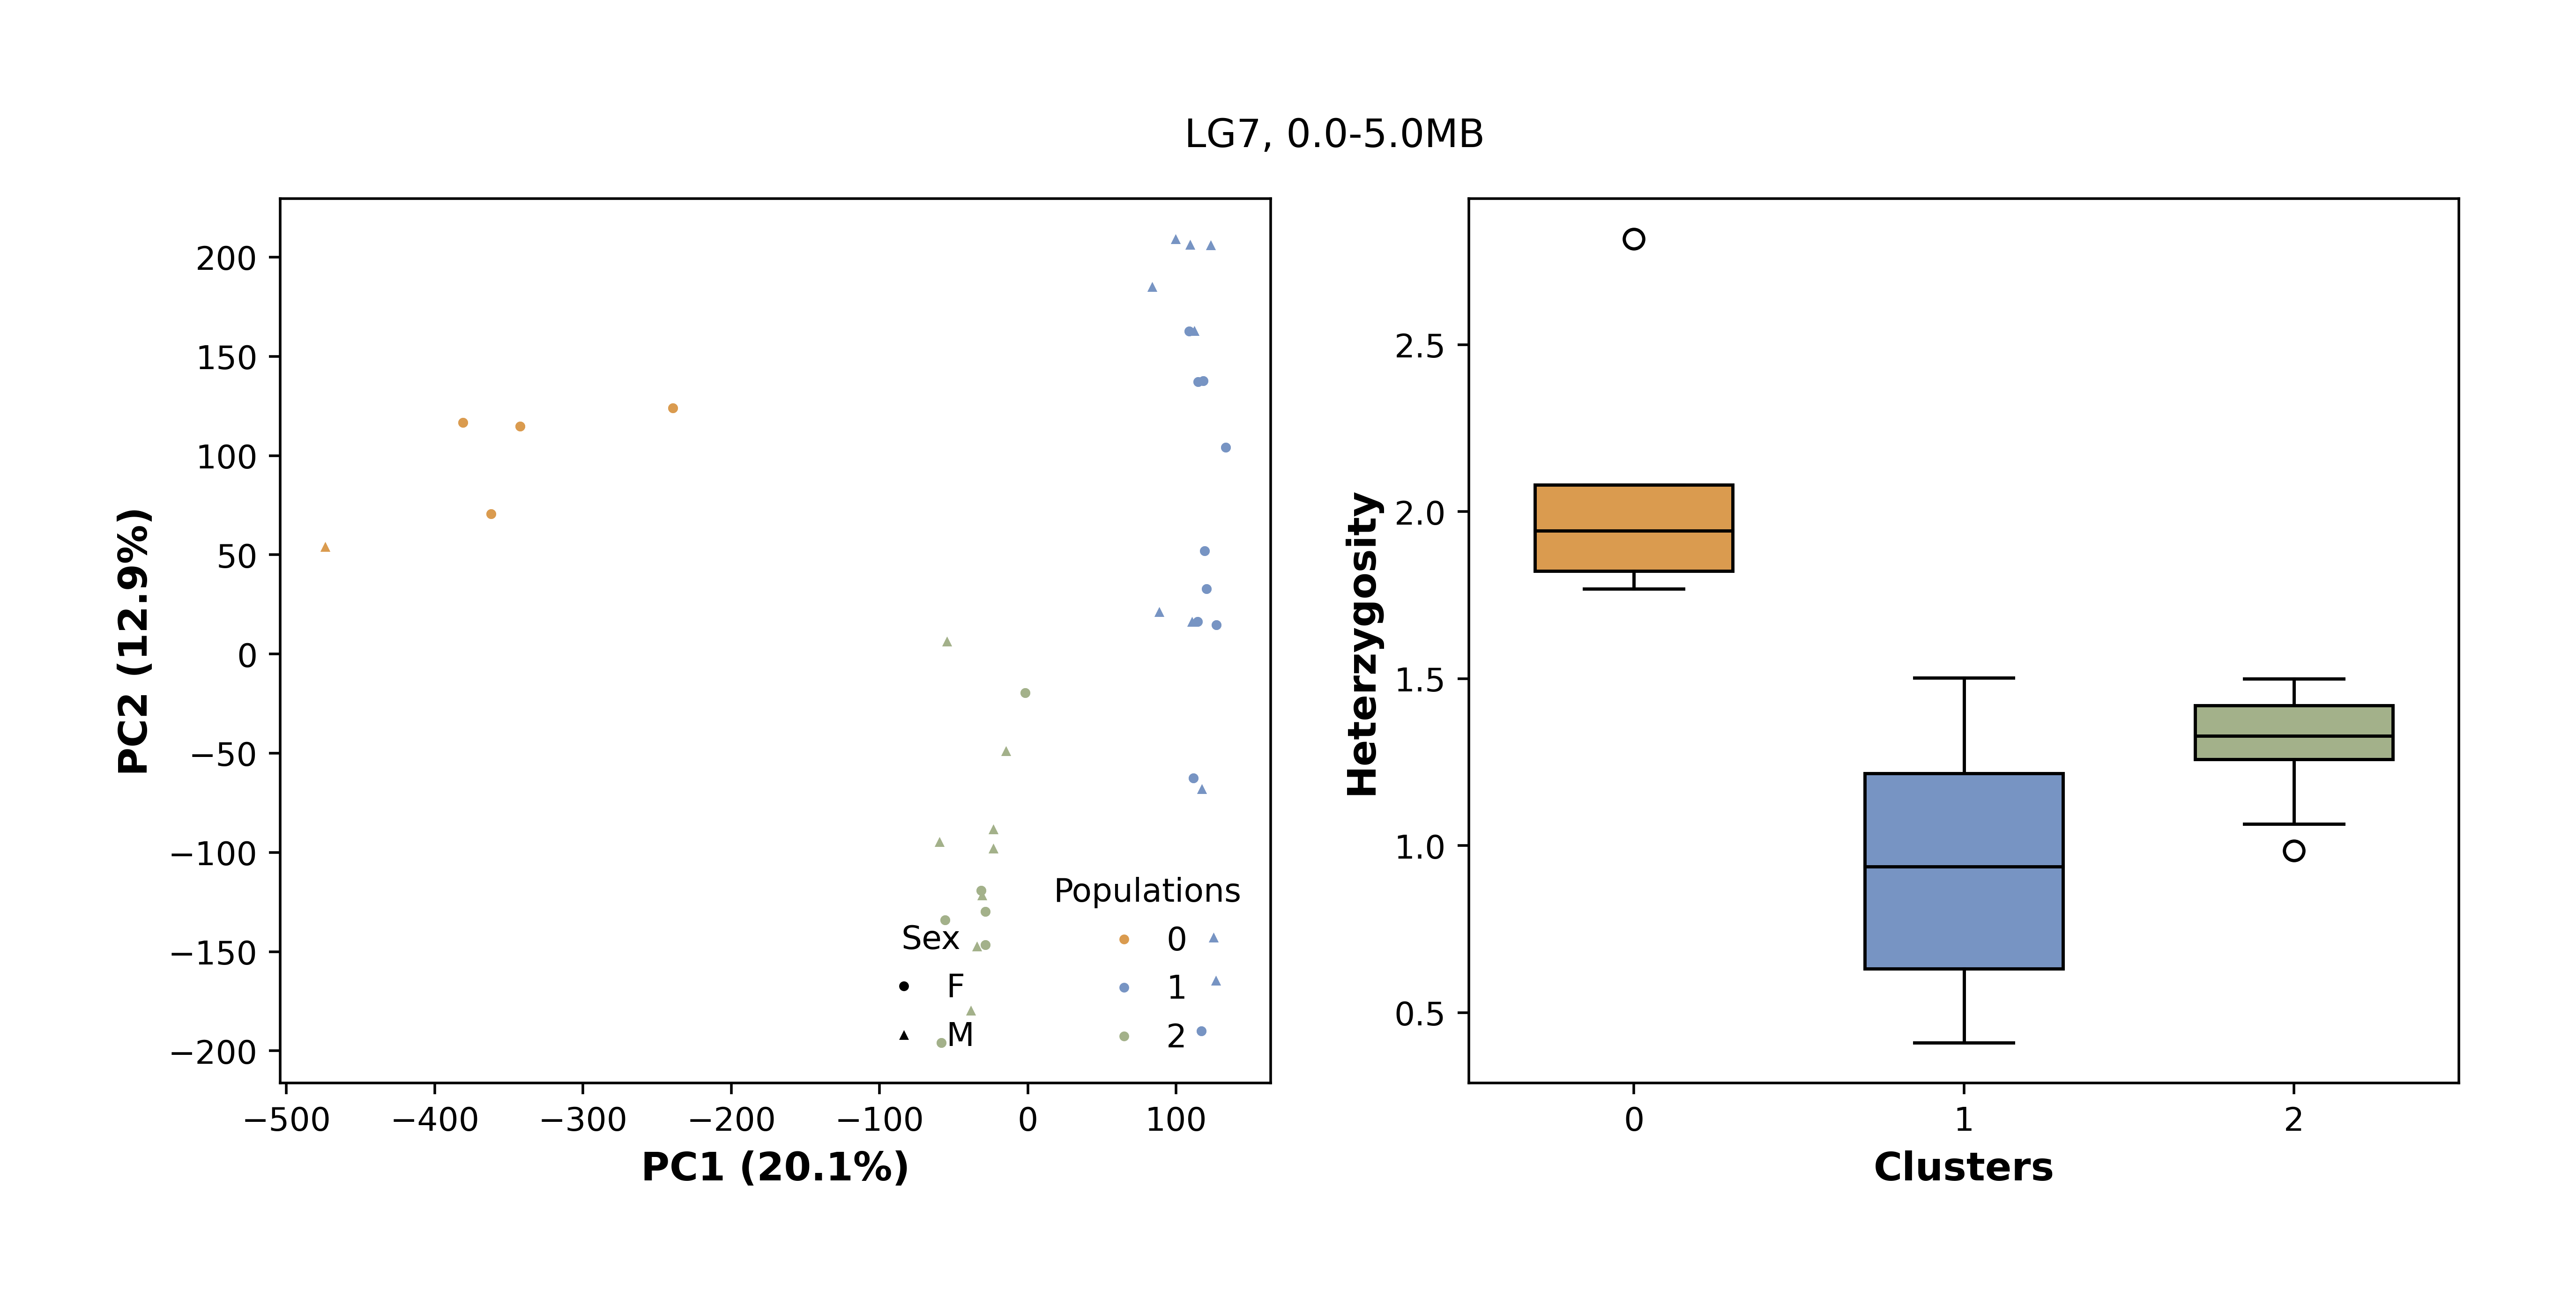

In [9]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
plt.figure(dpi = 500)
# plt.title("LG12, 2-3.5MB")
fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi = 500)
fig.suptitle("LG7, {}-{}MB".format(str(int(start)/1000000), str(int(end)/1000000)), y=0.95)

# Read data into a pandas dataframe

#cluster_colors = {'0':'#DA9B4F', '1':'#7794C3', '2':'#A3B18A'}
sex_markers = {"F":"o", "M":"^"}
#pop_colors = {"QUH": "#DA9B4F", "QUL": '#7794C3'}
#pop_colors = {'QUH':'#DA9B4F', 'QUL':'#A3B18A'}
pop_colors = {'0':'#DA9B4F', '1':'#7794C3', '2':'#A3B18A'}
# Plot the clusters
for pop in pop_colors.keys():
    for s in sex_markers.keys():
        subset = df[(df['cluster'] == int(pop)) & (df['sex'] == s)]
        axs[0].scatter(subset['PC1'], subset['PC2'], color=pop_colors[pop],
                       marker=sex_markers[s], label=f'{pop}')
        axs[0].scatter(subset['PC1'], subset['PC2'], color=pop_colors[pop],
                       marker=sex_markers[s], label=f'{s}')
        
##### previous 
# for pop in cluster_colors.keys():
#     for s in sex.keys():
#         subset = df[(df['cluster'] == int(pop)) & (df['sex'] == s)]
#         axs[0].scatter(subset['PC1'], subset['PC2'], color=cluster_colors[pop],
#                        marker=sex_markers[s], label=f'{pop}')
#         axs[0].scatter(subset['PC1'], subset['PC2'], color=cluster_colors[pop],
#                        marker=sex_markers[s], label=f'{s}')
        
# # Add legend for population
handles, labels = [], []
for pop in pop_colors.keys():
    handles.append(plt.scatter([], [], color=pop_colors[pop], marker='o'))
    labels.append(pop)
first_legend = axs[0].legend(handles, labels, title='Populations', loc="lower right")
axs[0].add_artist(first_legend)

# # Add legend for sex
handles, labels = [], []
for s in sex_markers.keys():
    handles.append(plt.scatter([], [], color='black', marker=sex_markers[s]))
    labels.append(s)
axs[0].legend(handles, labels, title='Sex', loc=[0.60, 0.02])

# lables
pc1=0
pc2=1

axs[0].set_xlabel(('PC%s (%.1f%%)' % (pc1+1, model1.explained_variance_ratio_[pc1]*100)), fontsize=12, fontweight="bold")
axs[0].set_ylabel(('PC%s (%.1f%%)' % (pc2+1, model1.explained_variance_ratio_[pc2]*100)), fontsize=12, fontweight="bold")



# Fig 2.1 Define the colors

# plot violin plot for cluster 0
bplot1 = axs[1].boxplot(df.loc[df["cluster"] == 0, "hetero"], positions=[0], widths=0.6, 
                        patch_artist=True, medianprops=dict(color="black"))

# plot violin plot for cluster 0
bplot2 = axs[1].boxplot(df.loc[df["cluster"] == 1, "hetero"], positions=[1], widths=0.6,
                        patch_artist=True,  medianprops=dict(color="black"))

# plot violin plot for cluster 1
bplot3 = axs[1].boxplot(df.loc[df["cluster"] == 2, "hetero"], positions=[2], widths=0.6,
                        patch_artist=True,  medianprops=dict(color="black"))
              
colors = ['#DA9B4F', '#7794C3', '#A3B18A']
# Set the facecolor for each box
for bplot, color in zip([bplot1, bplot2, bplot3], colors):
    for patch in bplot['boxes']:
        patch.set_color(color)
        patch.set_facecolor(color)
        patch.set_edgecolor("black")
axs[1].set_xticklabels(["0", "1", "2"])

axs[1].set_xlabel("Clusters", fontsize=12, fontweight="bold")
axs[1].set_ylabel("Heterzygosity", fontsize=12, fontweight="bold")

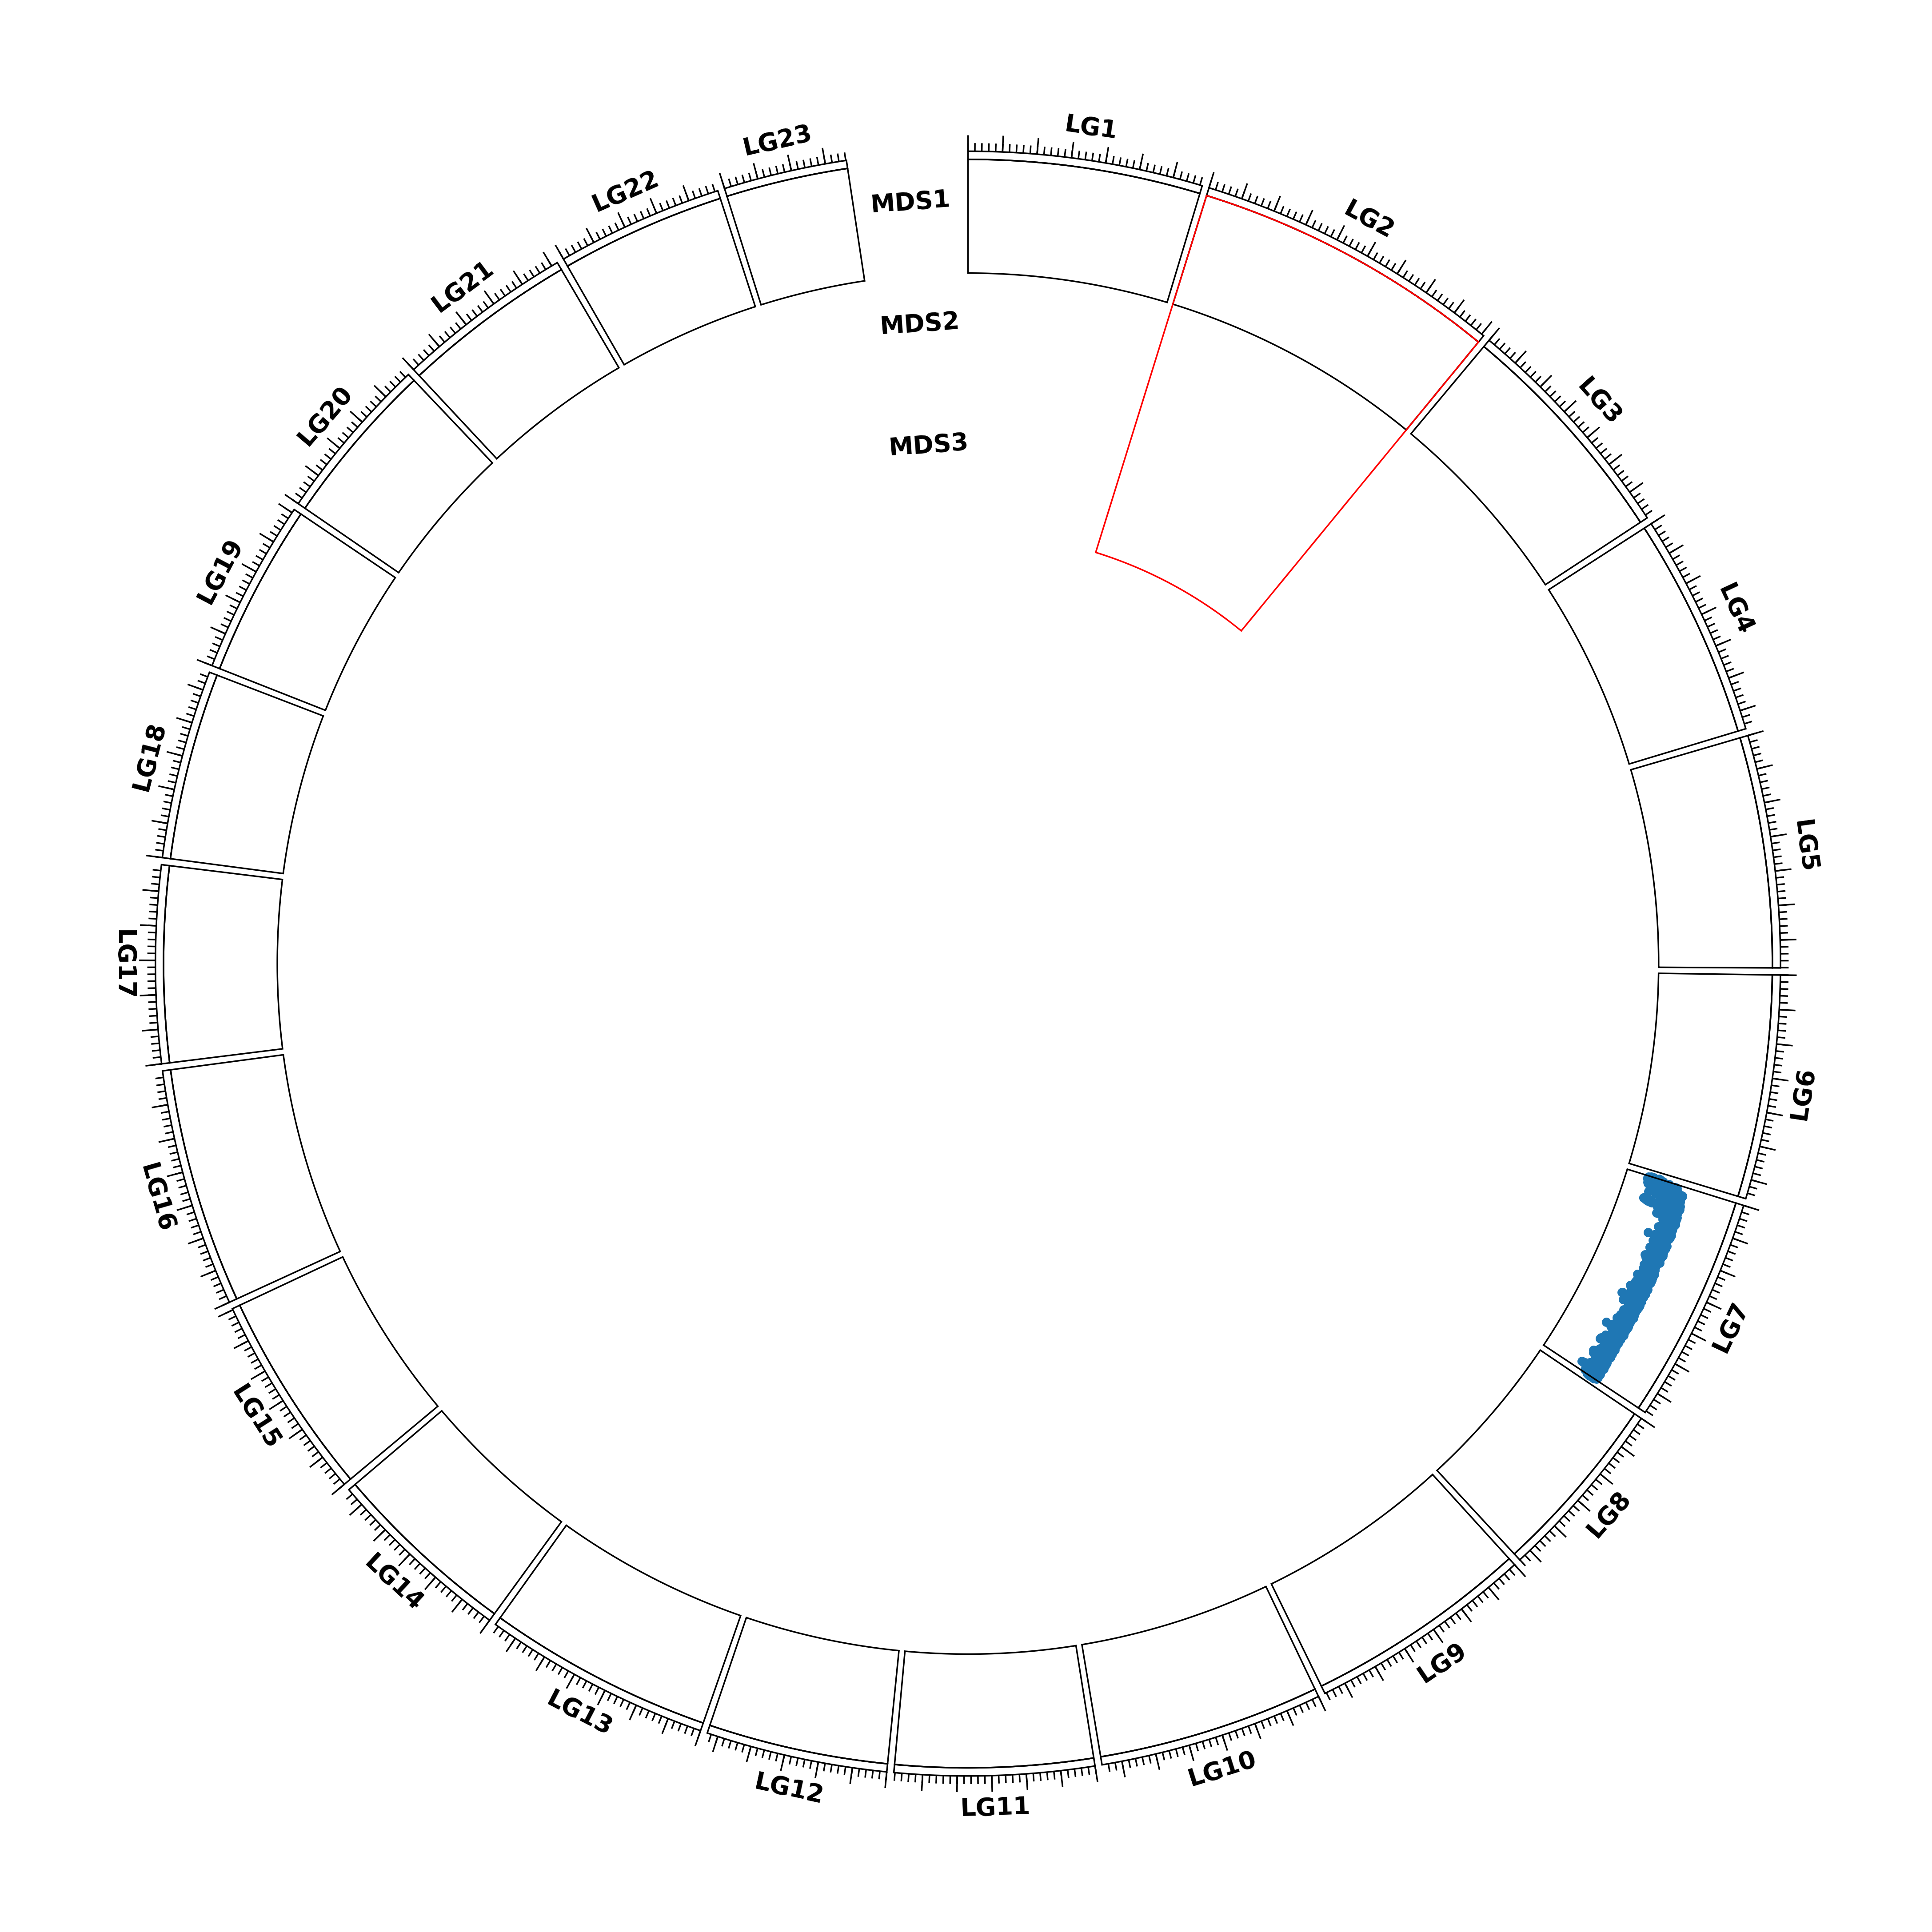

In [290]:
sectors = {"1": 34.343053, "2": 45.373629, "3": 34.494140, "4": 32.745292, "5": 34.046079,
          "6": 32.826315, "7": 33.249287, "8": 27.016956, "9": 33.240922, "10": 32.921471,
          "11": 29.172019, "12": 26.605240, "13": 33.504201, "14": 27.818384, "15": 30.184557,
          "16": 34.948840, "17": 28.869038, "18": 27.716212, "19": 25.553809, "20": 24.586947,
          "21": 25.956221, "22": 24.441338, "23": 18.095316, "24":15.586947}
circos = Circos(sectors, space=0.5, start=0, end=360)
for sector in circos.sectors[:23]:
    # Plot sector name
    sector.text(f"LG{sector.name}", r=102.5, size=8, fontweight="bold")
    
    # Create x positions & randomized y values for data plotting
#     x = np.arange(sector.start, sector.end) + 0.5
#     y = np.random.randint(0, 100, len(x))
    
    # Plot line
    line_track = sector.add_track((99, 100), r_pad_ratio=0.1)

    line_track.axis()
    line_track.xticks_by_interval(1, show_label=False, tick_length=1)
    line_track.xticks_by_interval(5, show_label=False, tick_length=2)
    #line_track.xticks([5,10])
    
    line_track = sector.add_track((85, 99), r_pad_ratio=0.1)
    line_track.axis()
    #line_track.scatter(x.to_list(), y.to_list())
    
    # Plot points
#     points_track = sector.add_track((70, 84), r_pad_ratio=0.1)
#     points_track.axis()
#     points_track.scatter(x, y)
    # Plot bar
#     bar_track = sector.add_track((55, 69), r_pad_ratio=0.1)
#     bar_track.axis()
#     bar_track.bar(x, y)
    


# y axis
circos.sectors[6].add_track((85,99), r_pad_ratio=0.1).scatter(x.to_list(), y.to_list(), vmin=-1, vmax=1)
#circos.sectors[22].add_track((85, 99), r_pad_ratio=0.1).yticks([-1,0,1], tick_length=0.5, labels=["-1","0","1"], label_size=8)
circos.sectors[1].add_track((53, 99), r_pad_ratio=0.1).axis(ec="red")

### circo labels
circos.sectors[23].text("MDS1", r=92.5, size=8, fontweight="bold", ha="center")
circos.sectors[23].text("MDS2", r=77.5, size=8, fontweight="bold", ha="center")
circos.sectors[23].text("MDS3", r=62.5, size=8, fontweight="bold", ha="center")
    
# second
#sectors = {"note":10}
# circos2 = Circos(sectors, space=0.5,start=10, end=360)
# for sector in circos2.sectors:
#     sector.text("a", r=92.5, size=8, fontweight="bold")

#circos2 = Circos(sectors, space=0.5, start=0, end=20)
# text_common_kws = dict(ha="center", va="center", size=8, fontweight="bold")
# circos.text("MDS1", r=92.5, color="black", **text_common_kws, deg=1.5)
# circos.text("MDS2", r=77.5, color="black", **text_common_kws,deg=0.75)
# circos.text("MDS3", r=62.5, color="black", **text_common_kws)
# text_common_kws = dict(ha="left", va="center", size=15, fontweight="bold")
# circos.text("Happy Weekend!!!", r=35, color="black", **text_common_kws, deg=300)
# circos.text("Why am I still plotting???", r=40, color="black", **text_common_kws, deg=278)
# circos.text("Cause I enjoy doing science!!!", r=45, color="black", **text_common_kws, deg=260)
# circos.text("??? Really ???", r=35, color="black", **text_common_kws, deg=230)

fig = circos.plotfig(dpi=500) 
fig.savefig("/Users/rainlam/Desktop/circos_test.tiff", format="tiff")
fig.savefig("/Users/rainlam/Desktop/circos_test.pdf", format="pdf")

In [215]:
?line_track.yticks

In [271]:
?line_track.scatter

In [159]:
?circos.sectors

In [177]:
for sector in circos.sectors[:23]:
    print(sector)

# Sector = '1'
# Size = 10 (0 - 10)
# Radian size = 0.18 (0.17 - 0.35)
# Degree size = 10.09 (10.00 - 20.09)

# Sector = '2'
# Size = 15 (0 - 15)
# Radian size = 0.26 (0.36 - 0.62)
# Degree size = 15.13 (20.59 - 35.72)

# Sector = '3'
# Size = 12 (0 - 12)
# Radian size = 0.21 (0.63 - 0.84)
# Degree size = 12.11 (36.22 - 48.33)

# Sector = '4'
# Size = 20 (0 - 20)
# Radian size = 0.35 (0.85 - 1.20)
# Degree size = 20.18 (48.83 - 69.01)

# Sector = '5'
# Size = 15 (0 - 15)
# Radian size = 0.26 (1.21 - 1.48)
# Degree size = 15.13 (69.51 - 84.64)

# Sector = '6'
# Size = 10 (0 - 10)
# Radian size = 0.18 (1.49 - 1.66)
# Degree size = 10.09 (85.14 - 95.23)

# Sector = '7'
# Size = 15 (0 - 15)
# Radian size = 0.26 (1.67 - 1.94)
# Degree size = 15.13 (95.73 - 110.87)

# Sector = '8'
# Size = 12 (0 - 12)
# Radian size = 0.21 (1.94 - 2.16)
# Degree size = 12.11 (111.37 - 123.48)

# Sector = '9'
# Size = 20 (0 - 20)
# Radian size = 0.35 (2.16 - 2.52)
# Degree size = 20.18 (123.98 - 144.16)

# Sec